<a href="https://colab.research.google.com/github/renzzheng/Pokemon_TCG_Price_Model/blob/main/Pokemon_TCG_Price_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


Authors: Elijah Alexandre, Timothy Jeon, Ren-Zhi Zheng


---
### STAGE 1 — Project Proposal
- Pokemon TCG API https://pokemontcg.io/
- Credit: Andrew Backes

### Problem:
- We are attempting to explore whether AI models can be used to predict Pokémon card market prices using only card metadata, and to identify which features are most influential in determining the projected price of a card.
- *We do not currently have time-data available, so we are not able to forecast predicted costs with this AI model.*

### Preliminary Thoughts:
- Baseline Linear Regression to use as an example
- Neural Networks?
- Random Forest (Tree-Based)
- Features to use:
  - Price because that is our obvious target.
  - Other features are more important indicators of values such as popular pokemon, card rarity, card artist, and set name.

### How We Intend to Evaluate and Interpret Model Results:
- Compare MSE and R² values across testing and training results, and different models.

- Compare predicted prices to actual prices for each model.

- For the Random Forest feature predictions, we compared the top 10 predicted most influential features against the actual top 10 features to result in the greatest returns.



---
### STAGE 2 — Model Development and Justification

In [ ]:
# (a) load in everything
import requests
import time
import json
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_PATH = "/content/drive/MyDrive/Pokemon_TCG_AI"

In [ ]:
# OPTIONAL: API
url = "https://api.pokemontcg.io/v2/cards"
API_KEY = os.getenv("POKEMONTCG_API_KEY")

In [ ]:
# (b) connect to google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# OPTIONAL: attempting to paginate through entire API database to get all cards
PAGE_SIZE = 250 # maximum amount of cards to return

headers = {
    "X-Api-Key": API_KEY,
    "Accept": "application/json"
}

all_cards = []
page = 1

while True:
    params = {
        "page": page,
        "pageSize": PAGE_SIZE
    }

    try:
      response = requests.get(url, headers=headers, params=params)
      response.raise_for_status()
      data = response.json()

    except requests.exceptions.RequestException as e:
      print(f"[ERROR] Page {page} failed: {e}")
      print("Skipping page and continuing to next...\n")
      page += 1
      time.sleep(1.0)  # being polite to the API :)
      continue

    cards = data.get("data", [])

    if not cards:
      print("No more cards. Pagination was a success! It's a healthy dataset! :D")
      break

    all_cards.extend(cards)
    print(f"Fetched page {page} ({len(cards)} cards)")

    page += 1
    time.sleep(0.3)  # being polite to the API :)

    if len(cards) == 0:
        break  # no more pages

print(f"Total cards collected: {len(all_cards)}")


[ERROR] Page 1 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=1&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 2 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=2&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 3 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=3&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 4 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=4&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 5 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=5&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 6 failed: 404 Client Error: Not Found for url: https://api.pokemontcg.io/v2/cards?page=6&pageSize=250
Skipping page and continuing to next...

[ERROR] Page 7 failed: 404 Client Error: Not Found for url: http

In [ ]:
# (c) preserve the dataset into google drive
os.makedirs(BASE_PATH, exist_ok=True)

with open(f"{BASE_PATH}/all_cards_1.json", "w") as f:
    json.dump(all_cards, f)

In [ ]:
# (d) load in the dataset
with open(f"{BASE_PATH}/all_cards_1.json", "r") as f:
    all_cards = json.load(f)

print(f"Loaded {len(all_cards)} cards")


Loaded 5000 cards


In [ ]:
# (e) clean and build a dataset csv file
def build_dataset(all_cards):
    rows = []

    for card in all_cards:
        # skip cards without a market price
        price = None

        tcgplayer = card.get("tcgplayer")
        if tcgplayer and "prices" in tcgplayer:
            for variant in tcgplayer["prices"].values():
                if "market" in variant and variant["market"] is not None:
                    price = variant["market"] # set to market price
                    break

        if price is None:
            continue

        # build rows (target = price)
        row = {
            "id": card.get("id"),
            "name": card.get("name"),
            "rarity": card.get("rarity", "Unknown"),
            "supertype": card.get("supertype", "Unknown"),
            "subtypes": ",".join(card.get("subtypes", [])),
            "set_id": card.get("set", {}).get("id"),
            "set_name": card.get("set", {}).get("name"),
            "release_date": card.get("set", {}).get("releaseDate"),
            "artist": card.get("artist"),
            "price": price
        }

        rows.append(row)

    return pd.DataFrame(rows)

# (f) save csv to google drive
df = build_dataset(all_cards)
df.to_csv(f"{BASE_PATH}/pokemon_cards_subset.csv", index=False)

In [ ]:
# (1) load in the csv dataset
df = pd.read_csv(f"{BASE_PATH}/pokemon_prices_2026-01-25.csv")

In [ ]:
# (2a) trim and train the data
# ensure the column exists before encoding
if "rarity" not in df.columns:
    # add a default rarity column (or compute differently)
    df["rarity"] = "None"

df["rarity_code"] = df["rarity"].astype("category").cat.codes
print(df)

       card_id                 name          variant  \
0      hgss4-1               Aggron         holofoil   
1      hgss4-1               Aggron  reverseHolofoil   
2        xy5-1               Weedle           normal   
3        xy5-1               Weedle  reverseHolofoil   
4        pl1-1             Ampharos         holofoil   
...        ...                  ...              ...   
33000  me2-126             Rotom ex         holofoil   
33001  me2-127     Mega Sharpedo ex         holofoil   
33002  me2-128      Mega Lopunny ex         holofoil   
33003  me2-129                 Dawn         holofoil   
33004  me2-130  Mega Charizard X ex         holofoil   

                          rarity supertype         subtypes set_id  \
0                      Rare Holo   Pokémon          Stage 2  hgss4   
1                      Rare Holo   Pokémon          Stage 2  hgss4   
2                         Common   Pokémon            Basic    xy5   
3                         Common   Pokémon     

In [ ]:
# (2b) get cleaned card subjects shown on cards
import re

def extract_card_subject(name):
    name = str(name).strip()

    # remove star symbol
    name = name.replace("★", "").strip()

    # remove common suffixes/forms at the END, allowing space or hyphen before them
    cleaned = re.sub(
        r'[\s-]+(VMAX|VSTAR|GX|EX|ex|BREAK|LV\.X|Prime|V|G|δ|FB)$',
        '',
        name
    )

    # remove prefixes/forms at the START
    cleaned = re.sub(
        r'^(Radiant|Shining|Dark|Light|M|Mega|Special Delivery)\s+',
        '',
        cleaned
    )

    # remove owner/team/possessive prefixes
    cleaned = re.sub(
        r"^(Blaine|Sabrina|Rocket|Team Magma|Team Aqua|Misty|Erika|Giovanni|Lt\. Surge|Brock)'s\s+",
        '',
        cleaned
    )

    # remove descriptions like "Pikachu with Grey Felt Hat"
    cleaned = re.sub(
        r'\s+with\s+.*$',
        '',
        cleaned
    )

    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned


def split_card_subject(subject):
    subject = str(subject).strip()

    # split duo / TAG TEAM subjects
    parts = [p.strip() for p in subject.split("&")]
    parts = [p for p in parts if p]
    return parts


df["card_subject"] = df["name"].apply(extract_card_subject)
# replace card_subject with individual subject list
df["card_subject_parts"] = df["card_subject"].apply(split_card_subject)
df[["name", "card_subject", "card_subject_parts", "subtypes"]].head(50)

,name,card_subject,card_subject_parts,subtypes
0,Aggron,Aggron,[Aggron],Stage 2
1,Aggron,Aggron,[Aggron],Stage 2
2,Weedle,Weedle,[Weedle],Basic
3,Weedle,Weedle,[Weedle],Basic
4,Ampharos,Ampharos,[Ampharos],Stage 2
5,Ampharos,Ampharos,[Ampharos],Stage 2
6,Ampharos,Ampharos,[Ampharos],Stage 2
7,Ampharos,Ampharos,[Ampharos],Stage 2
8,Bulbasaur,Bulbasaur,[Bulbasaur],Basic
9,Dratini,Dratini,[Dratini],Basic


In [ ]:
# (3) feature target/test split

# keep only the most common individual card subjects
all_subjects = df["card_subject_parts"].explode()

top_subjects = all_subjects.value_counts().head(300).index

def limit_subjects(parts):
    kept = [p for p in parts if p in top_subjects]
    return kept if kept else ["Other"]

df["card_subject_parts_limited"] = df["card_subject_parts"].apply(limit_subjects)

# convert individual card subjects into binary features
mlb = MultiLabelBinarizer()

card_subject_features = pd.DataFrame(
    mlb.fit_transform(df["card_subject_parts_limited"]),
    columns=["card_subject_" + name for name in mlb.classes_],
    index=df.index
).astype(np.int8)

# one-hot encode regular categorical columns
X_base = pd.get_dummies(
    df.drop(
        columns=[
            "card_id",
            "name",
            "market_price",
            "card_subject",
            "card_subject_parts",
            "card_subject_parts_limited"
        ],
        errors="ignore"
    ),
    drop_first=True,
    dtype=np.int8
)

# combine metadata features with individual card subject features
X = pd.concat([X_base, card_subject_features], axis=1)
y = df["market_price"]


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# baseline linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

preds_lr = lr.predict(X_test_scaled)

print("Linear Regression MAE:", mean_absolute_error(y_test, preds_lr))
print("Linear Regression R²:", r2_score(y_test, preds_lr))

Linear Regression MAE: 15.61521178377871
Linear Regression R²: 0.28215575914456636


### LINEAR REGRESSION INTERPRETATION

- MAE: `15.62`
  - On average, the Linear Regression model's predictions are off by about `$15.62` per card-price observation.
  - This error is meaningful, especially for lower-priced cards where a `$15` difference can be large relative to the actual price.

- R²: `0.282`
  - The model explains about `28.2%` of the variation in market prices.
  - This suggests that the linear model captures some pricing signal from the metadata, but it does not explain most of the variation in card prices.

### LIMITATIONS

- Linear Regression assumes a mostly linear relationship between the encoded features and market price, which may be too simple for collectible card pricing.
- The model likely struggles with rare high-value outliers.
- Card prices are influenced by additional factors not fully captured in the dataset.

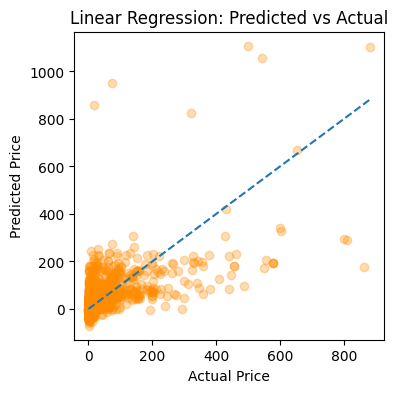

In [ ]:
# (4) plot the linear regression model
plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_lr, alpha=0.3, color="darkorange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="dashed",
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

### SCALED LINEAR MODEL INTERPRETATION

- The Linear Regression model shows limited predictive performance.
- Its predicted-vs-actual plot shows that many predictions cluster around lower prices and do not fully capture the spread of actual card prices.
  - This suggests that the relationship between card metadata and market price is likely not purely linear.
  - Because of this, I tested regularized linear models and nonlinear models to see whether they could better capture pricing patterns.

alpha: 1
Test MAE: 15.615144396201318
Test R²: 0.28224474199213956

alpha: 10
Test MAE: 15.615240254540295
Test R²: 0.2828722511573477

alpha: 50
Test MAE: 15.60810186312739
Test R²: 0.28482545096652834

alpha: 100
Test MAE: 15.586784328135987
Test R²: 0.28717912547507274

alpha: 500
Test MAE: 15.385471417697453
Test R²: 0.3043269703792333

alpha: 1000
Test MAE: 15.162393515758378
Test R²: 0.32072803722961996

Ridge Regression:
Train MAE: 15.585287978445148
Test  MAE: 15.162393515758378
Train R²: 0.3807701119179093
Test  R²: 0.32072803722961996


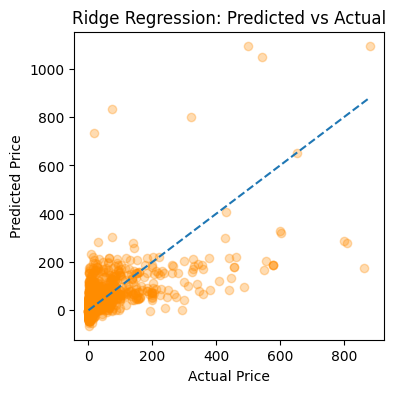

In [ ]:
# (5) apply ridge
for alpha in [1, 10, 50, 100, 500, 1000]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    preds = ridge.predict(X_test_scaled)

    print("alpha:", alpha)
    print("Test MAE:", mean_absolute_error(y_test, preds))
    print("Test R²:", r2_score(y_test, preds))
    print()

# ridge on training data
preds_ridge_train = ridge.predict(X_train_scaled)

# ridge on testing data
preds_ridge_test = ridge.predict(X_test_scaled)

print("Ridge Regression:")
print("Train MAE:", mean_absolute_error(y_train, preds_ridge_train))
print("Test  MAE:", mean_absolute_error(y_test, preds_ridge_test))
print("Train R²:", r2_score(y_train, preds_ridge_train))
print("Test  R²:", r2_score(y_test, preds_ridge_test))

# plot it
plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_ridge_test, alpha=0.3, color="darkorange")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
    linestyle="dashed")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Predicted vs Actual")
plt.show()

### RIDGE REGRESSION INTERPRETATION

- Best alpha tested: `1000`

- Train MAE: `15.59`
- Test MAE: `15.16`
  - On average, the Ridge model's predictions are off by about `$15.16` on unseen test data.
  - This is slightly better than the baseline Linear Regression model.

- Train R²: `0.381`
- Test R²: `0.321`
  - The model explains about `38.1%` of the variation in training prices and about `32.1%` of the variation in test prices.
  - Compared to Linear Regression, Ridge improved test R²from about `0.282` to `0.321`, suggesting that stronger regularization helped stabilize the model.

### LIMITATIONS

- Ridge Regression improved performance slightly, but it still leaves most of the price variation unexplained.
- The predicted-vs-actual plot shows that the model captures the dense cluster of low- and mid-priced cards, but *still* struggles with rare high-value cards.

Lasso Regression:
Train MAE: 15.585287978445148
Test  MAE: 11.70114717740405
Train R²: 0.3807701119179093
Test  R²: 0.2756520805231174


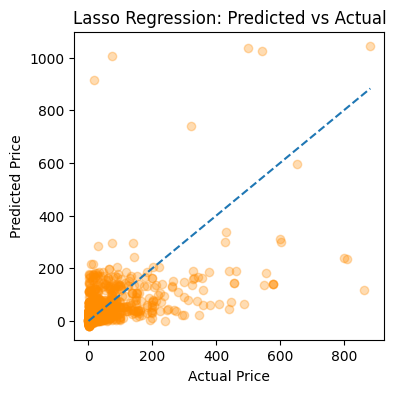

In [ ]:
# (6) apply lasso
lasso = Lasso(
    alpha=1.0,          # stronger regularization = faster convergence
    max_iter=5000,      # don't let it run forever
    tol=0.01,           # looser tolerance = faster
    selection="random", # often faster for high-dimensional data
    random_state=42
)
lasso.fit(X_train_scaled, y_train)

# lasso on training data
preds_lasso_train = ridge.predict(X_train_scaled)

# lasso on testing data
preds_lasso_test = lasso.predict(X_test_scaled)

print("Lasso Regression:")
print("Train MAE:", mean_absolute_error(y_train, preds_lasso_train))
print("Test  MAE:", mean_absolute_error(y_test, preds_lasso_test))
print("Train R²:", r2_score(y_train, preds_lasso_train))
print("Test  R²:", r2_score(y_test, preds_lasso_test))

# plot it
plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_lasso_test, alpha=0.3, color="darkorange")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
    linestyle="dashed")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Predicted vs Actual")
plt.show()


### LASSO REGRESSION INTERPRETATION

- Train MAE: `15.59`
- Test MAE: `11.70`
  - On average, the Lasso model's predictions are off by about `$11.70` on unseen test data.
  - This is a noticeable improvement in test MAE compared to Linear Regression and Ridge Regression.

- Train R²: `0.381`
- Test R²: `0.276`
  - The model explains about 38.1% of the variation in training prices and about 27.6% of the variation in test prices.
  - Although Lasso reduced the average prediction error, its lower test R² suggests that it does not explain the overall spread of card prices as well as Ridge Regression.

### LIMITATIONS

- Lasso may have removed useful one-hot encoded features while shrinking less useful features.
- The predicted-vs-actual plot shows that the model still struggles with high-value outliers.
- This result shows why MAE and R² should both be considered:
  - Lasso performed better in terms of average dollar error, but worse in explaining overall price variation.

Elastic Net Test MAE: 15.49786480782607
Elastic Net Test R²: 0.2892354490815313


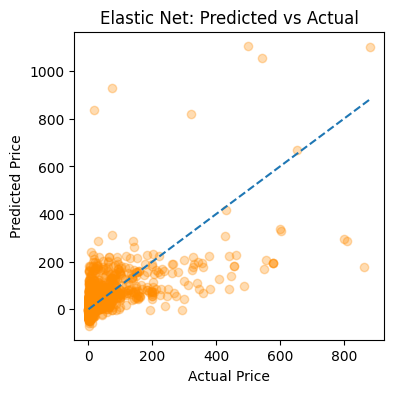

In [ ]:
# (7) apply both lasso + ridge
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=100000)
elastic.fit(X_train_scaled, y_train)

preds_elastic = elastic.predict(X_test_scaled)

print("Elastic Net Test MAE:", mean_absolute_error(y_test, preds_elastic))
print("Elastic Net Test R²:", r2_score(y_test, preds_elastic))

# plot it
plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_elastic, alpha=0.3, color="darkorange")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
    linestyle="dashed")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Elastic Net: Predicted vs Actual")
plt.show()


### ELASTIC NET INTERPRETATION

- Test MAE: `15.50`
  - On average, the Elastic Net model's predictions are off by about `$15.50` on unseen test data.
  - This is similar to Linear Regression and slightly worse than Ridge Regression.

- Test R²: `0.289`
  - The model explains about `28.9%` of the variation in test prices.
  - This is slightly better than Linear Regression, but lower than Ridge Regression.

### LIMITATIONS

- Elastic Net combines Ridge and Lasso regularization, but in this experiment it did not outperform either model.
  - Ridge explained more overall price variation, while Lasso achieved a lower average prediction error.
- The predicted-vs-actual plot shows that Elastic Net captures the dense cluster of low- and mid-priced cards, but still struggles with rare high-value outliers.

---

### CONCLUSION

Elastic Net performed similarly to Linear Regression but did not outperform Ridge Regression or Lasso Regression in this experiment.

Among the regularized linear models, Ridge explained the most overall price variation, while Lasso achieved the lowest average prediction error. However, all of the linear models still struggled to capture the full spread of card prices, especially rare high-value cards.

This suggests that Pokémon card pricing may depend on nonlinear feature interactions and external market factors that are not fully captured by linear models.
  - Because of this, I next tested Random Forest models to better capture more complex relationships between card metadata and market price.

---

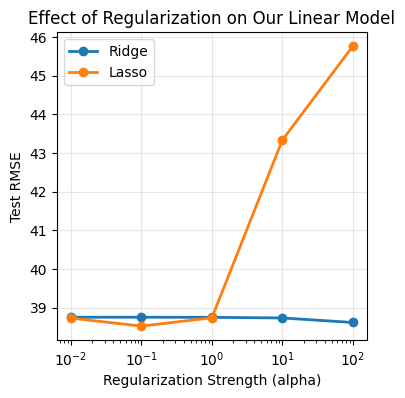

In [ ]:
# (8) plotting ridge and lasso effect on linear model
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_rmse = []
lasso_rmse = []

for a in alphas:
    # Ridge
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    ridge_model.fit(X_train, y_train)
    ypr = ridge_model.predict(X_test)
    ridge_rmse.append(math.sqrt(mean_squared_error(y_test, ypr)))

    # Lasso
    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=100000))
    ])
    lasso_model.fit(X_train, y_train)
    ypl = lasso_model.predict(X_test)
    lasso_rmse.append(math.sqrt(mean_squared_error(y_test, ypl)))

# plot it
plt.figure(figsize=(4,4))
plt.plot(alphas, ridge_rmse, marker="o", linewidth=2, label="Ridge")
plt.plot(alphas, lasso_rmse, marker="o", linewidth=2, label="Lasso")
plt.xscale("log")
plt.xlabel("Regularization Strength (alpha)")
plt.ylabel("Test RMSE")
plt.title("Effect of Regularization on Our Linear Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



Random Forest Regression:
Train MAE: 12.865355576846289
Test  MAE: 11.67855178901163
Train R²: 0.22612110498042037
Test  R²: 0.364563396244979


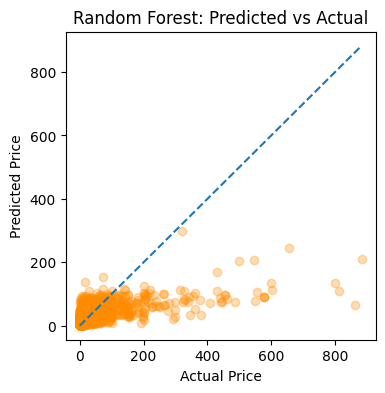

In [ ]:
# (9a) try to do a random forest model now
rf = RandomForestRegressor(
    n_estimators=75,
    max_depth=22,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    max_samples=0.6,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# predictions
preds_rf_train = rf.predict(X_train)
preds_rf_test  = rf.predict(X_test)

print("Random Forest Regression:")
print("Train MAE:", mean_absolute_error(y_train, preds_rf_train))
print("Test  MAE:", mean_absolute_error(y_test, preds_rf_test))
print("Train R²:", r2_score(y_train, preds_rf_train))
print("Test  R²:", r2_score(y_test, preds_rf_test))

# plot the random forest model
plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_rf_test, alpha=0.3, color="darkorange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="dashed",
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()


*RANDOM FOREST INTERPRETATION:*

- Train MAE: 12.87
- Test MAE: 11.68
  - On average, the standard Random Forest model’s predictions are off by about $11.68 on unseen test data.
  - This is better than the linear models in terms of test MAE.

- Train R²: 0.226
- Test R²: 0.365
  - The model explains about 36.5% of the variation in test prices.
  - This is stronger than the linear models, suggesting that Random Forest captured some nonlinear relationships between card metadata and market price.

- The predicted-vs-actual plot shows that the model performs reasonably well for low- and mid-priced cards, where most of the data is concentrated.
  - However, predictions are compressed toward lower prices, and the model still underpredicts many high-value cards.

- Overall, the standard Random Forest improved over the linear models, but it still struggled with expensive outliers.

Random Forest with Log Price Target:
Train MAE: 3.199330058341578
Test MAE: 5.364913062206201
Train R²: 0.7888726898621261
Test R²: 0.6605184300757316


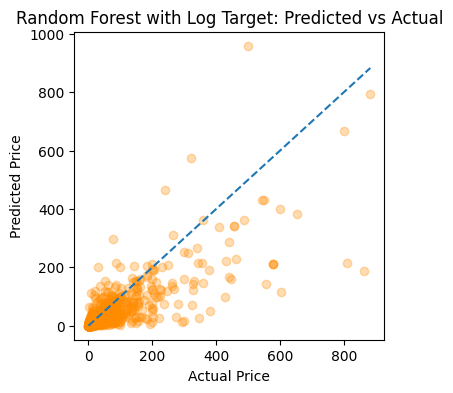

In [ ]:
# (9b) random forest model with log transformation

# log-transform target
y_train_log = np.log1p(y_train)

rf_log = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train, y_train_log)

# predict log prices, then convert back to dollar prices
preds_rf_log_train = np.expm1(rf_log.predict(X_train))
preds_rf_log_test = np.expm1(rf_log.predict(X_test))

# avoid negative weirdness
preds_rf_log_train = np.maximum(preds_rf_log_train, 0)
preds_rf_log_test = np.maximum(preds_rf_log_test, 0)

print("Random Forest with Log Price Target:")
print("Train MAE:", mean_absolute_error(y_train, preds_rf_log_train))
print("Test MAE:", mean_absolute_error(y_test, preds_rf_log_test))
print("Train R²:", r2_score(y_train, preds_rf_log_train))
print("Test R²:", r2_score(y_test, preds_rf_log_test))

plt.figure(figsize=(4,4))
plt.scatter(y_test, preds_rf_log_test, alpha=0.3, color="darkorange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="dashed"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest with Log Target: Predicted vs Actual")
plt.show()

*RANDOM FOREST WITH LOG TARGET INTERPRETATION:*

- Train MAE: 3.20
- Test MAE: 5.36
  - On average, the log-target Random Forest model’s predictions are off by about $5.36 on unseen test data.
  - This is the lowest test MAE among all models tested.

- Train R²: 0.789
- Test R²: 0.661
  - The model explains about 78.9% of the variation in training prices and about 66.1% of the variation in test prices.
  - This is the highest test R² among all models tested.

- The predicted-vs-actual plot shows a much stronger relationship between actual and predicted prices than the standard Random Forest.
  - The model still underpredicts some high-value cards, but it captures the overall price trend much better.

- Overall, the log-target Random Forest was the strongest model in this experiment. The log transformation helped the model handle the highly skewed distribution of Pokémon card prices, where most cards are low-priced but a small number of cards are extremely expensive.

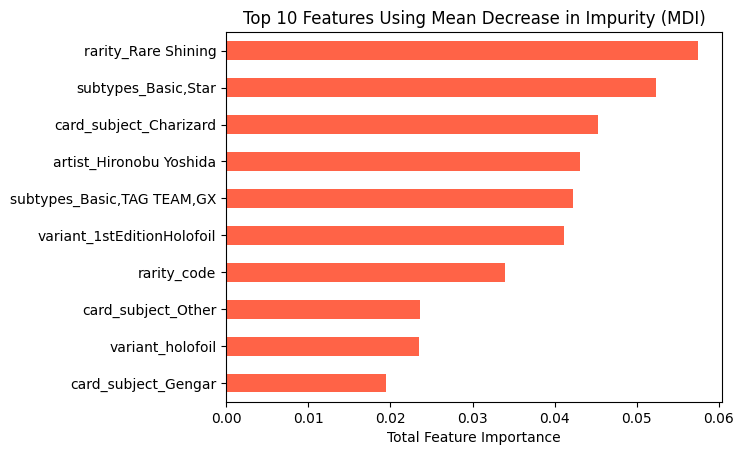

In [ ]:
# (10) get feature importances
importances = rf.feature_importances_

# create a Series for easy sorting and plotting
feature_importances = (
    pd.Series(importances, index=X_train.columns)
    .nlargest(10)
    .iloc[::-1]
)

# plot the top N most important features
feature_importances.plot(kind="barh", color="tomato")
plt.title("Top 10 Features Using Mean Decrease in Impurity (MDI)")
plt.xlabel("Total Feature Importance")
plt.show()

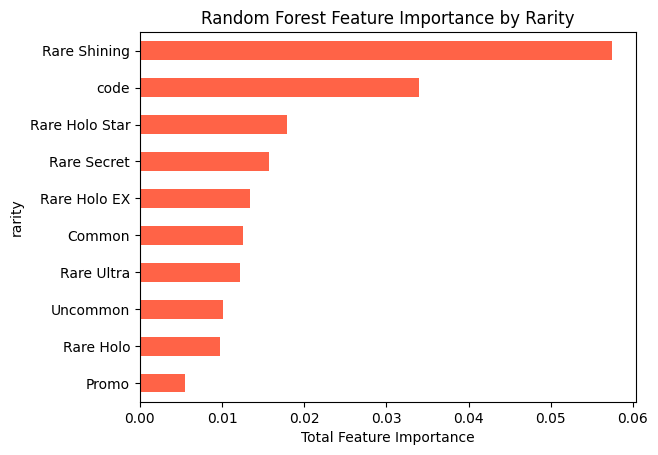

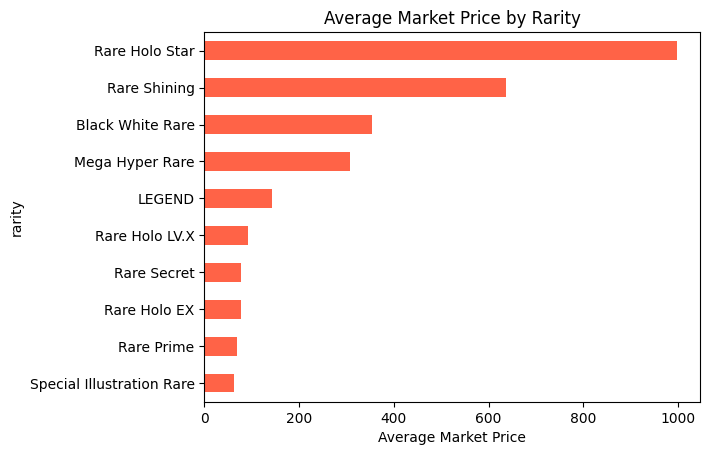

In [ ]:
# (11) get rarity importances
imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

# only focus on rarity one-hot features
rarity_imp = imp_df[imp_df["feature"].str.startswith("rarity_")].copy()

# remove one-hot prefix
rarity_imp["rarity"] = rarity_imp["feature"].str.replace("rarity_", "", regex=False)

# get top 10 rarity importances
rarity_importance = (
    rarity_imp
    .groupby("rarity")["importance"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .iloc[::-1]
)

# plot feature importance by rarity
rarity_importance.plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Total Feature Importance")
plt.title("Random Forest Feature Importance by Rarity")
plt.show()


# Average market price by rarity
avg_price_by_rarity = (
    df.groupby("rarity")["market_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# plot average market price by rarity
avg_price_by_rarity_plot = avg_price_by_rarity.iloc[::-1]

avg_price_by_rarity_plot.plot(
    kind="barh",
    color="tomato"
)

plt.xlabel("Average Market Price")
plt.title("Average Market Price by Rarity")
plt.show()


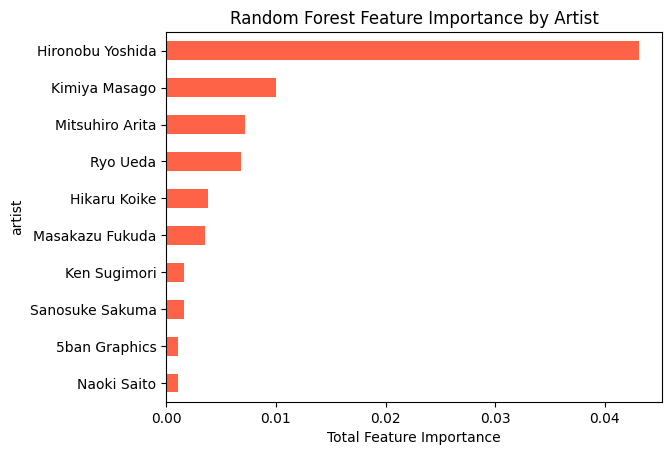

,market_price
artist,
USGMEN,258.675000
Hironobu Yoshida,215.458507
Sakiko Maeda,198.810000
Craig Turvey,184.420000
Yusuke Shimada,175.500000
Noriko Uono,171.630000
Shinji Higuchi,171.250000
Kimiya Masago,163.204091
Yasuki Watanabe,159.300000


In [ ]:
# (12) get artist importances
imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

artist_imp = imp_df[imp_df["feature"].str.startswith("artist_")].copy()

artist_imp["artist"] = artist_imp["feature"].str.replace("artist_", "", regex=False)

artist_importance = (
    artist_imp
    .groupby("artist")["importance"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .iloc[::-1]
)

# plot it
artist_importance.head(10).plot(
    kind="barh",
    color="tomato"
)
plt.xlabel("Total Feature Importance")
plt.title("Random Forest Feature Importance by Artist")
plt.show()

df.groupby("artist")["market_price"].mean().sort_values(ascending=False).head(10)

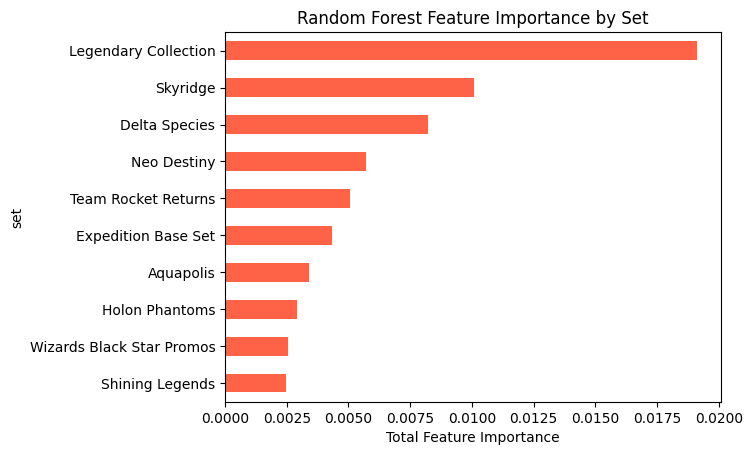

,market_price
set_name,
POP Series 5,124.562500
Pokémon Rumble,109.047500
Legendary Collection,83.836637
Best of Game,83.492222
Neo Destiny,83.010959
Nintendo Black Star Promos,72.199487
Wizards Black Star Promos,68.747143
Skyridge,64.863934
Southern Islands,63.949444


In [ ]:
# (13) get set importances
imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# only focusing on set names
set_imp = imp_df[imp_df["feature"].str.startswith("set_name_")].copy()

# get set name and importance only (top 10)
set_imp["set"] = set_imp["feature"].str.replace("set_name_", "", regex=False)

set_importance = (
    set_imp
    .groupby("set")["importance"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .iloc[::-1]
)

# plot it
set_importance.plot(kind="barh", color="tomato")
plt.title("Random Forest Feature Importance by Set")
plt.xlabel("Total Feature Importance")
plt.show()

df.groupby("set_name")["market_price"].mean().sort_values(ascending=False).head(10)



---

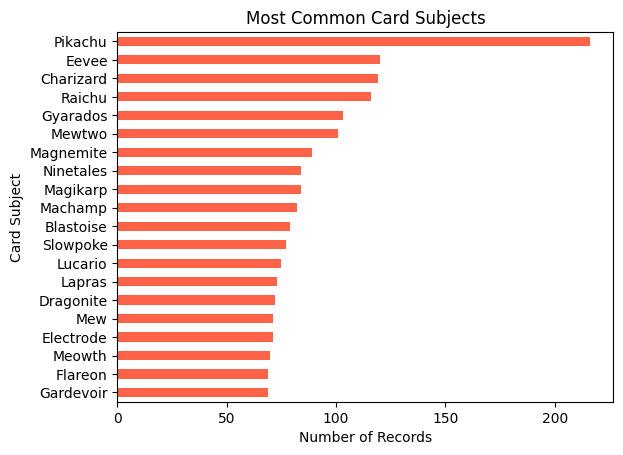

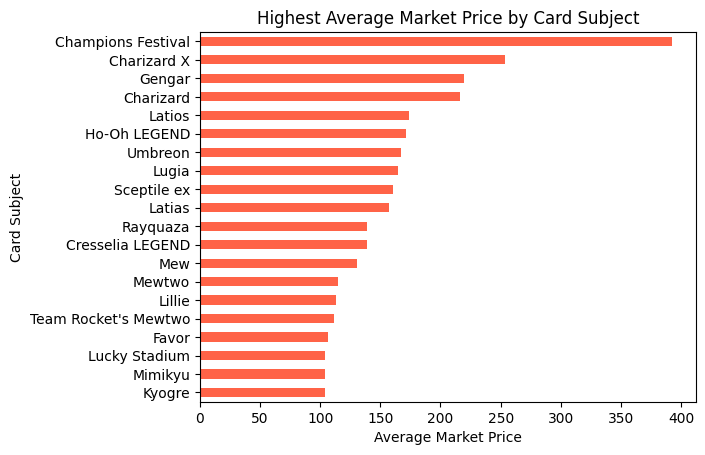

In [ ]:
# (14) card subject analysis
# explode list column so each individual subject gets its own row
subject_df = (
    df[["card_subject_parts", "market_price"]]
    .explode("card_subject_parts")
    .rename(columns={"card_subject_parts": "card_subject"})
)


# most common card subjects
subject_counts = (
    subject_df["card_subject"]
    .value_counts()
    .head(20)
)

# plot most common card subjects
subject_counts_plot = subject_counts.iloc[::-1]

subject_counts_plot.plot(kind="barh", color="tomato")
plt.title("Most Common Card Subjects")
plt.xlabel("Number of Records")
plt.ylabel("Card Subject")
plt.show()


# average market price by subject
subject_summary = (
    subject_df
    .groupby("card_subject")
    .agg(
        avg_market_price=("market_price", "mean"),
        num_records=("market_price", "count")
    )
)

# filter out subjects that appear fewer than 3 times
subject_summary_filtered = (
    subject_summary[subject_summary["num_records"] >= 3]
    .sort_values("avg_market_price", ascending=False)
    .head(20)
)

# plot average market price by subject
subject_price_plot = subject_summary_filtered["avg_market_price"].iloc[::-1]

subject_price_plot.plot(kind="barh", color="tomato")
plt.title("Highest Average Market Price by Card Subject")
plt.xlabel("Average Market Price")
plt.ylabel("Card Subject")
plt.show()